# Ordinal Regression for activity data

Here we look at regression where the response variable is ordinal and look at the best way of finding good mutations. We start with preprocessed data. Then these are the steps

1. Import data and clean further
1. Look at package Mord for ordinal regression
1. Run regressions and save data


## Import Dataset and Post Process
Here we import the activity data and do a few post processing steps

1. Remove duplicate sequences 
1. Remove sequences with stops in the middle
1. Assign sequences to exactly one bin (based on where it is most likely)   
   **TODO (if needed)**: We can look at schemes like weighting a sequence into different bins based on read counts


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import Bio
import Bio.Seq

In [2]:
df = pd.read_pickle("data/azid_activity.pkl")

print("\n>> Response Value Counts")
print(df.response.value_counts())
print(f"\n>> Number of sequences : {len(df)}")
N = len(df.iloc[0].sequence)
print(f"\n>> Length of a sequence : {N}")
print(f"\n>> Number of unique sequences : {len(df.sequence.unique())}")
df.head()


>> Response Value Counts
0    706
1    177
2     54
3     23
Name: response, dtype: int64

>> Number of sequences : 960

>> Length of a sequence : 274

>> Number of unique sequences : 905


,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9941,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,8031,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,5729,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3147,3


In [3]:
# WildType Sequence
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
WT_full = Bio.Seq.Seq(WT_DNA).translate()
WT_full

Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*', HasStopCodon(ExtendedIUPACProtein(), '*'))

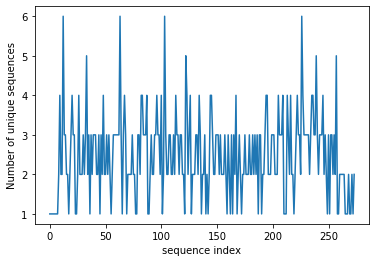

In [4]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence.str.get(i).unique()) for i in range(N)])
plt.plot(num_unique)
plt.xlabel("sequence index")
plt.ylabel("Number of unique sequences");

In [5]:
# location of the first stop sequence
df["first_stop"] = df.sequence.str.find("*")
num_stops_in_middle = (df.first_stop != (N-1)).sum()
print(f">> Number of sequences with a stop before the end : {num_stops_in_middle}")

# print out wherever we have a stop in the middle
#df[df.first_stop != (N-1)]

>> Number of sequences with a stop before the end : 33


In [6]:
df_nostop = df[df.first_stop == (len(WT_full) -1)].drop(columns=['first_stop'])
df_nostop.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9941,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,8031,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,5729,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3147,3


In [7]:
# Where is WildType in this dataframe
df_nostop[df_nostop.sequence == WT_full]

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1185,1
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,515,0


In [8]:
# Replace non-unique sequences with their response category with the highest count
df_unique = df_nostop.sort_values('count', ascending=False).groupby('sequence').head(1).reset_index(drop=True)
df_unique.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16082,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,12035,2
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9704,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,4234,2


In [9]:
# Where is WT in this dataframe
# It should be at the top
WT_in_df = df_unique[df_unique.sequence==WT_full]
if WT_in_df.index[0] != 0:
    print(" >> WARNING: WT is not at the top of the dataframe")
WT_in_df

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2


In [10]:
# Drop the Start and STOP Codons
df_unique.sequence = df_unique.sequence.str.slice(1, (len(WT_full)-1))
WT = WT_full[1:-1]
WT_str = str(WT)
N = len(WT_str)

## Ordinal regression

We are using the [mord package](https://github.com/fabianp/mord) to do ordinal regression. The steps in this section are 
1. Create design matrix and response vector
2. Run a cross validated search for the best regularization parameter
3. Save coefficients

In [11]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score

import mord
from mord import LogisticAT

In [12]:
y = df_unique.response.to_numpy()
design_cols = df_unique.sequence.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
enc = OneHotEncoder(
    drop=None, # don't drop columns 
    sparse=False ) # setting to False for now

X = enc.fit_transform(design_cols)
print(X.shape)
X

(872, 656)


array([[1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       ...,
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.]])

In [13]:
# Try out model with alpha = 1.0. This will get overwritten in the gridsearch
model = mord.LogisticAT(alpha=1.0)

model.fit(X, y)

# The score is negative of mean absolute error between prediction and response vector
print(f"Model Score with alpha={model.alpha} : {model.score(X, y):.2f}")

Model Score with alpha=1.0 : -0.14


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

In [15]:
# Create pipeline with mord so that we are removing features that are all one
# Also we are standardizing features by their mean and standard deviation
pipeline = Pipeline([('vt', VarianceThreshold()), 
                     ('scaler', StandardScaler()), 
                     ('model', model)])

alphas = np.logspace(-6, 2, 10) # search space for regularization params
grid_cv = GridSearchCV(estimator=pipeline, param_grid=dict(model__alpha=alphas), 
                       cv=StratifiedKFold(5), n_jobs=5, iid='deprecated')
_ = grid_cv.fit(X, y)

>> Grid Search best params : {'model__alpha': 12.915496650148826}


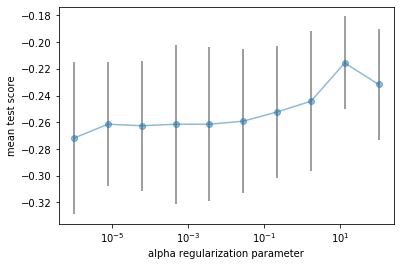

In [16]:
# regularization parameter picked by CV
print(f">> Grid Search best params : {grid_cv.best_params_}")

plt.errorbar(alphas, grid_cv.cv_results_["mean_test_score"],
             grid_cv.cv_results_["std_test_score"], fmt='-o', ecolor="black", alpha=0.5)
plt.xscale('log')
plt.xlabel("alpha regularization parameter")
plt.ylabel("mean test score");

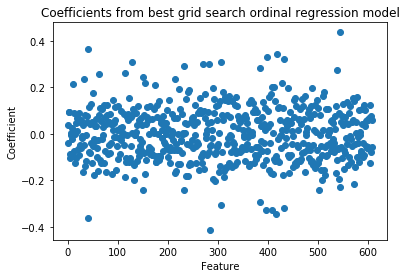

In [17]:
# Now fit the model with the best parameter to the entire dataset
best_model = grid_cv.best_estimator_
best_alpha = best_model.get_params()['model__alpha']

best_model.fit(X, y)
best_coefs = grid_cv.best_estimator_['model'].coef_

plt.plot(best_coefs, 'o')
plt.title("Coefficients from best grid search ordinal regression model")
plt.xlabel("Feature")
plt.ylabel("Coefficient");

In [18]:
# Find feature names after the variance threshold
vt = grid_cv.best_estimator_.named_steps['vt']
feature_names_after_threshold = enc.get_feature_names()[vt.get_support()]

best_results = pd.DataFrame({'feature':feature_names_after_threshold, 'coef':best_coefs})
# extract the Residue index and the AA mutation 
best_results[["idx", "aa_mut"]] = \
    best_results.feature.str.extractall(r"x([0-9]+)_([A-Z])").reset_index(drop=True)
best_results["idx"] = best_results.idx.astype(int)

best_results["aa_wt"] = pd.Series([WT_str[i] for i in best_results.idx])
best_results["fname"] = best_results.aa_wt + \
                best_results.idx.astype(str) + best_results.aa_mut
best_results["N_obs"] = X.sum(axis=0)[vt.get_support()]

y3 = (y == 3)

def bin3_stats_pd(row):
    col = row.idx
    aa = row.aa_mut
    y_pred = (design_cols[col] == aa).astype(np.int)

    row["bin3_f1"] = f1_score(y3, y_pred)
    return row

best_results = best_results.apply(bin3_stats_pd, axis=1)
#best_results.head()

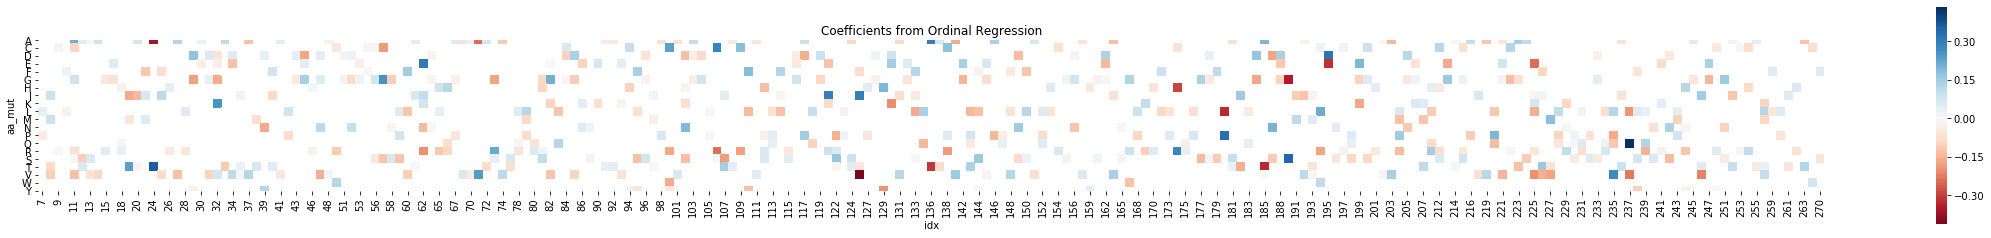

In [19]:
plt.figure(figsize=(40,4))
fig = sns.heatmap(best_results.pivot("aa_mut", "idx", "coef"), 
                  center = 0, cmap = 'RdBu', square = True)
plt.title("Coefficients from Ordinal Regression")
#plt.savefig('coeff_azid_heatmap.png', dpi=500)
pass

In [20]:
WT_one_hot = enc.transform([list(WT_str),])
WT_probs = model.predict_proba(WT_one_hot)
WT_score = WT_one_hot @ model.coef_

In [21]:
AAs = 'ACDEFGHIKLMNPQRSTVWY'

def mut_wt(idx, aa):
    mut = WT_str[:idx] + aa + WT_str[(idx+1):]
    return mut

# Create a single mutant for each wildType
seqs = pd.Series([mut_wt(row['idx'], row['aa_mut']) for idx, row in best_results.iterrows()])
mut_cols = seqs.apply(lambda x: pd.Series(list(x)))
mut_one_hot = enc.transform(mut_cols)

mut_score = mut_one_hot @ model.coef_ - WT_score

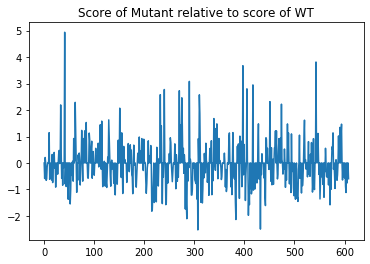

In [22]:
plt.plot(mut_score)
plt.title("Score of Mutant relative to score of WT");

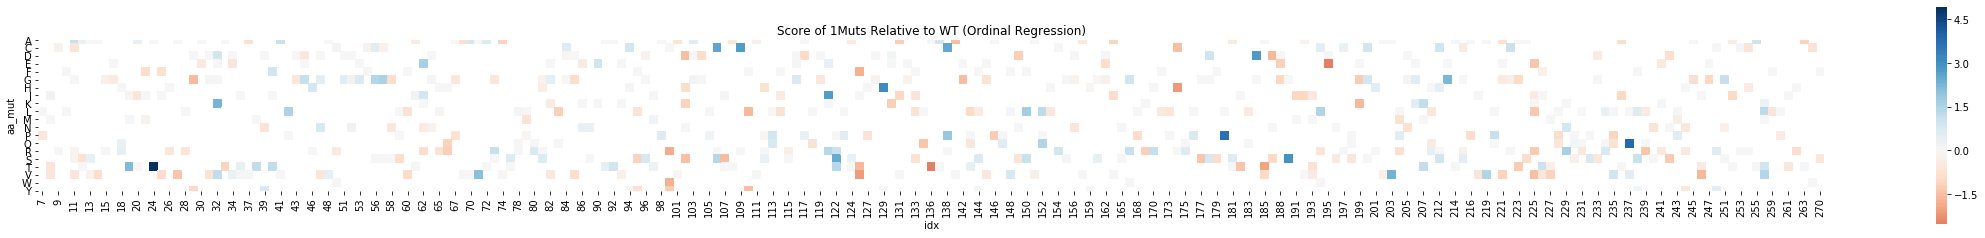

In [23]:
best_results["score_vs_wt"] = mut_score
plt.figure(figsize=(40,4))
fig = sns.heatmap(best_results.pivot("aa_mut", "idx", "score_vs_wt"), 
                  center = 0, cmap = 'RdBu', square = True)
plt.title("Score of 1Muts Relative to WT (Ordinal Regression)");
pass

In [24]:
best_results_no_wt = best_results[best_results.aa_mut != best_results.aa_wt]

In [25]:
descending_sort_results = best_results_no_wt.sort_values('score_vs_wt', ascending=False)
descending_sort_results.head(10)

,feature,coef,idx,aa_mut,aa_wt,fname,N_obs,bin3_f1,score_vs_wt
41,x24_T,0.363462,24,T,A,A24T,4.0,0.444444,4.936861
543,x237_Q,0.436565,237,Q,L,L237Q,3.0,0.352941,3.813932
397,x180_P,0.328705,180,P,L,L180P,4.0,0.333333,3.673305
290,x129_H,0.196595,129,H,Y,Y129H,4.0,0.000000,3.081714
417,x190_S,0.344590,190,S,G,G190S,5.0,0.210526,2.948196
405,x184_D,0.169668,184,D,G,G184D,3.0,0.000000,2.799977
240,x109_C,0.180825,109,C,R,R109C,1.0,0.133333,2.774915
270,x121_I,0.298522,121,I,K,K121I,3.0,0.000000,2.730013
232,x106_C,0.291693,106,C,R,R106C,8.0,0.000000,2.580632
310,x138_C,0.179769,138,C,R,R138C,4.0,0.000000,2.573930


In [26]:
import plotly.express as px

In [31]:
fig = px.scatter(best_results_no_wt, x="score_vs_wt", y="N_obs", hover_name="fname",
                title="Score of 1 mutants relative to WT (Ordinal Regression)")
fig.update_xaxes(range=[-3, 6])
fig.update_yaxes(range=[-5, 20])
fig.show()

img = fig.to_image(format="png", width=600, height=350, scale=2)
from IPython.display import Image
Image(img)

ValueError: Image generation requires the psutil package.

Install using pip:
    $ pip install psutil

Install using conda:
    $ conda install psutil


In [28]:
# Look at outliers
best_results_no_wt[best_results_no_wt.N_obs > 100]

,feature,coef,idx,aa_mut,aa_wt,fname,N_obs,bin3_f1,score_vs_wt
136,x63_N,0.006812,63,N,D,D63N,355.0,0.027100,-0.227898
256,x114_L,-0.125452,114,L,F,F114L,178.0,0.000000,-0.704786
503,x225_I,-0.005373,225,I,K,K225I,424.0,0.031963,-0.373714


In [29]:
def show_design_response(col_num, score_at=None, score=None, score_name="score"):
    ret =  pd.DataFrame({'aa':design_cols[col_num], 'response':y}).groupby(['aa', 'response']).size()
    ret = ret.to_frame()
    ret["res_idx"] = col_num
    ret.columns = ["count", "res_idx"]
    if score_at is not None:
        ret["score"] = np.nan
        ret.loc[score_at, score_name] = score
    return ret

def concat_design_response(df, col_name):
    return pd.concat(show_design_response(row.idx, row.aa_mut, row[col_name]) for
                    df_idx, row in df.iterrows())


In [30]:
# Detailed look at top results
ret_pd = concat_design_response(descending_sort_results[:8], "score_vs_wt")

for key, groupd in ret_pd.groupby(["res_idx"]):
    print (groupd)

             count  res_idx     score
aa response                          
A  0           647       24       NaN
   1           157       24       NaN
   2            54       24       NaN
   3            10       24       NaN
T  3             4       24  4.936861
             count  res_idx     score
aa response                          
C  3             1      109  2.774915
R  0           647      109       NaN
   1           157      109       NaN
   2            54      109       NaN
   3            13      109       NaN
             count  res_idx     score
aa response                          
E  0             6      121       NaN
   1             5      121       NaN
I  2             3      121  2.730013
K  0           638      121       NaN
   1           145      121       NaN
   2            51      121       NaN
   3            14      121       NaN
R  0             3      121       NaN
   1             7      121       NaN
             count  res_idx     score
aa response 